
# Data-Analysis Assignment 2: Linear Modeling of fMRI activity

Here we fit a linear model in order to understand the effect of sound being presented on the fMRI BOLD signal recorded from a human subject. We use a single predictor in our model, indicating when sound was `on` versus `off`. We will inspect the `design matrix`, fit our `linear model`, and examine the `contrast map` to see where in the brain the stimulus had a significant impact on activity. We will extract the `predicted` time series and compare with `actual` fMRI activity, inspect the `residuals`, and finally, we will assess the overall quality of our model fit in different areas of the brain by inspecting the `R-squared` value.   


## Import modules



In [1]:
# First, install the nilearn package
!pip install nilearn

import pandas as pd

from nilearn import image, masking
from nilearn.datasets import fetch_spm_auditory
from nilearn.plotting import plot_stat_map, show

# load fMRI data
subject_data = fetch_spm_auditory()
fmri_img = subject_data.func[0]

# Make an average
mean_img = image.mean_img(fmri_img)
mask = masking.compute_epi_mask(mean_img)

# Clean and smooth data
fmri_img = image.clean_img(fmri_img, standardize=None)
fmri_img = image.smooth_img(fmri_img, 5.0)

# load events
events = pd.read_csv(subject_data.events, sep="\t")

[fetch_spm_auditory] Dataset found in /Users/narayansankaran/nilearn_data/spm_auditory

## Fit model
Note that `minimize_memory` is set to `False` so that `FirstLevelModel`
stores the residuals.
`signal_scaling` is set to False, so we keep the same scaling as the
original data in `fmri_img`.



In [3]:
from nilearn.glm.first_level import FirstLevelModel

fmri_glm = FirstLevelModel(
    t_r=subject_data.t_r,
    drift_model="cosine",
    signal_scaling=False,
    mask_img=mask,
    minimize_memory=False,
    verbose=1,
)

fmri_glm = fmri_glm.fit(fmri_img, events)

[FirstLevelModel.fit] Loading mask from <nibabel.nifti1.Nifti1Image object at 0x15c180470>

[FirstLevelModel.fit] Loading data from <nibabel.nifti1.Nifti1Image object at 0x15b9cb920>

[FirstLevelModel.fit] Resampling mask

[FirstLevelModel.fit] Finished fit

[FirstLevelModel.fit] Computing run 1 out of 1 runs (go take a coffee, a big one).

[FirstLevelModel.fit] Performing mask computation.

[FirstLevelModel.fit] Loading data from <nibabel.nifti1.Nifti1Image object at 0x15b9cb920>

[FirstLevelModel.fit] Extracting region signals

[FirstLevelModel.fit] Cleaning extracted signals

[FirstLevelModel.fit] Masking took 0 seconds.

[FirstLevelModel.fit] Performing GLM computation.

[FirstLevelModel.fit] GLM took 0 seconds.

[FirstLevelModel.fit] Computation of 1 runs done in 0 seconds.


<div class='alert alert-warning'>
<b>ToDo</b>:

In your assignment document, answer *Question 1* about model fitting.
</div>

## Plot Design Matrix

Lets see what the design matrix looks like. We want to predict fMRI using a single predictor - whether there was any sound on/off.


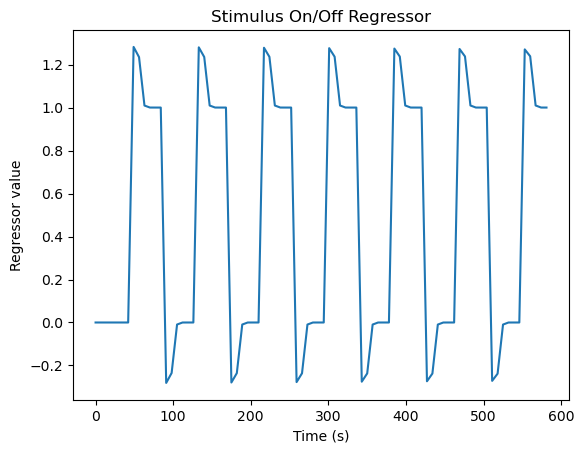

In [10]:
import matplotlib.pyplot as plt

# Get design matrix
design_matrix = fmri_glm.design_matrices_[0]
stim = design_matrix.iloc[:, 0]

plt.figure()
plt.plot(design_matrix.index, stim)
plt.xlabel("Time (s)")
plt.ylabel("Regressor value (a.u.)")
plt.title("Stimulus Design Matrix")
plt.show()





<div class='alert alert-warning'>
<b>ToDo</b>:

In your assignment document, answer *Question 2* about design matrices.
</div>

## Calculate and plot contrast

Rather than directly examining the beta weights, we will visualize them as a contrast map. In this map, we're conducting a t-test to see if beta was significantly greater or less than zero, and indicating the size of this effect using a colormap.

[FirstLevelModel.compute_contrast] Computing image from signals

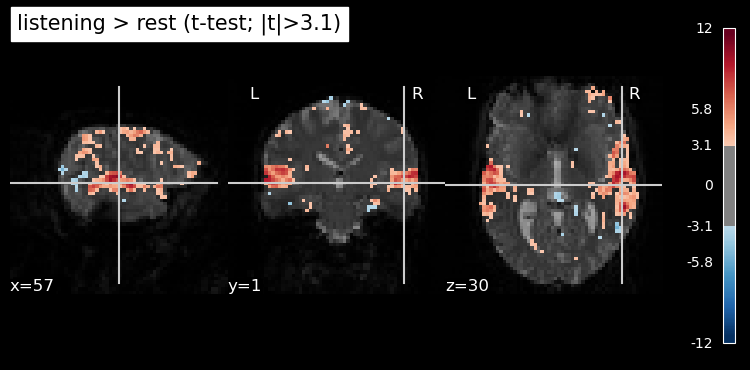

In [11]:
z_map = fmri_glm.compute_contrast("listening")

threshold = 3.1
plot_stat_map(
    z_map,
    bg_img=mean_img,
    threshold=threshold,
    title=f"listening > rest (t-test; |t|>{threshold})",
)

show()


<div class='alert alert-warning'>
<b>ToDo</b>:

In your assignment document, answer *Question 3* about beta weights and voxelwise contrast maps.
</div>

## Extract the largest clusters
Rather than looking at every voxel for further analysis, we can use an algorithm that "clusters" the beta weights into groups, and simply analyze each cluster. Lets now tell the algorithm to extract the 6 largest clusters, and get the x, y, and z coordinates of their peaks. We then extract the time series for each cluster.


In [12]:
from nilearn.maskers import NiftiSpheresMasker
from nilearn.reporting import get_clusters_table

table = get_clusters_table(
    z_map, stat_threshold=threshold, cluster_threshold=20
)
table.set_index("Cluster ID", drop=True)
print(table)

coords = table.loc[range(1, 7), ["X", "Y", "Z"]].to_numpy()
print(coords)

masker = NiftiSpheresMasker(coords, verbose=1)
real_timeseries = masker.fit_transform(fmri_img)
predicted_timeseries = masker.fit_transform(fmri_glm.predicted[0])

   Cluster ID     X     Y     Z  Peak Stat Cluster Size (mm3)
0           1 -60.0  -6.0  42.0  11.543910              20196
1          1a -51.0 -12.0  39.0  10.497958                   
2          1b -39.0 -12.0  39.0  10.118978                   
3          1c -63.0  12.0  33.0   9.754835                   
4           2  60.0   0.0  36.0  11.088600              32157
..        ...   ...   ...   ...        ...                ...
58         21  27.0 -72.0  27.0   4.422543                729
59        21a  24.0 -66.0  18.0   4.346647                   
60        21b  24.0 -78.0  21.0   3.428392                   
61         22 -30.0 -24.0  90.0   3.877083                648
62        22a -33.0 -18.0  72.0   3.791863                   

[63 rows x 6 columns]
[[-51. -12.  39.]
 [-39. -12.  39.]
 [-63.  12.  33.]
 [ 60.   0.  36.]
 [ 66.  12.  27.]
 [ 60. -18.  30.]]


[NiftiSpheresMasker.wrapped] Finished fit

[NiftiSpheresMasker.wrapped] Loading data from <nibabel.nifti1.Nifti1Image object at 0x15b9cb920>

[NiftiSpheresMasker.wrapped] Extracting region signals

[NiftiSpheresMasker.wrapped] Cleaning extracted signals

[FirstLevelModel.predicted] Computing image from signals

[NiftiSpheresMasker.wrapped] Finished fit

[NiftiSpheresMasker.wrapped] Loading data from <nibabel.nifti1.Nifti1Image object at 0x15ee1c3b0>

[NiftiSpheresMasker.wrapped] Extracting region signals

[NiftiSpheresMasker.wrapped] Cleaning extracted signals

To create new timeseries out of these clusters, we need to place spheres at their center. Let's have a look at the report to make sure
the spheres are well placed.



In [13]:
report = masker.generate_report()
report

## Plot predicted and actual time series for 6 most significant clusters

Now that we have our clusters, we can plot their fMRI timeseries as well as the model predictions. Underneath, we'll plot the contrast map and place a marker at the location on the brain of each cluster. 


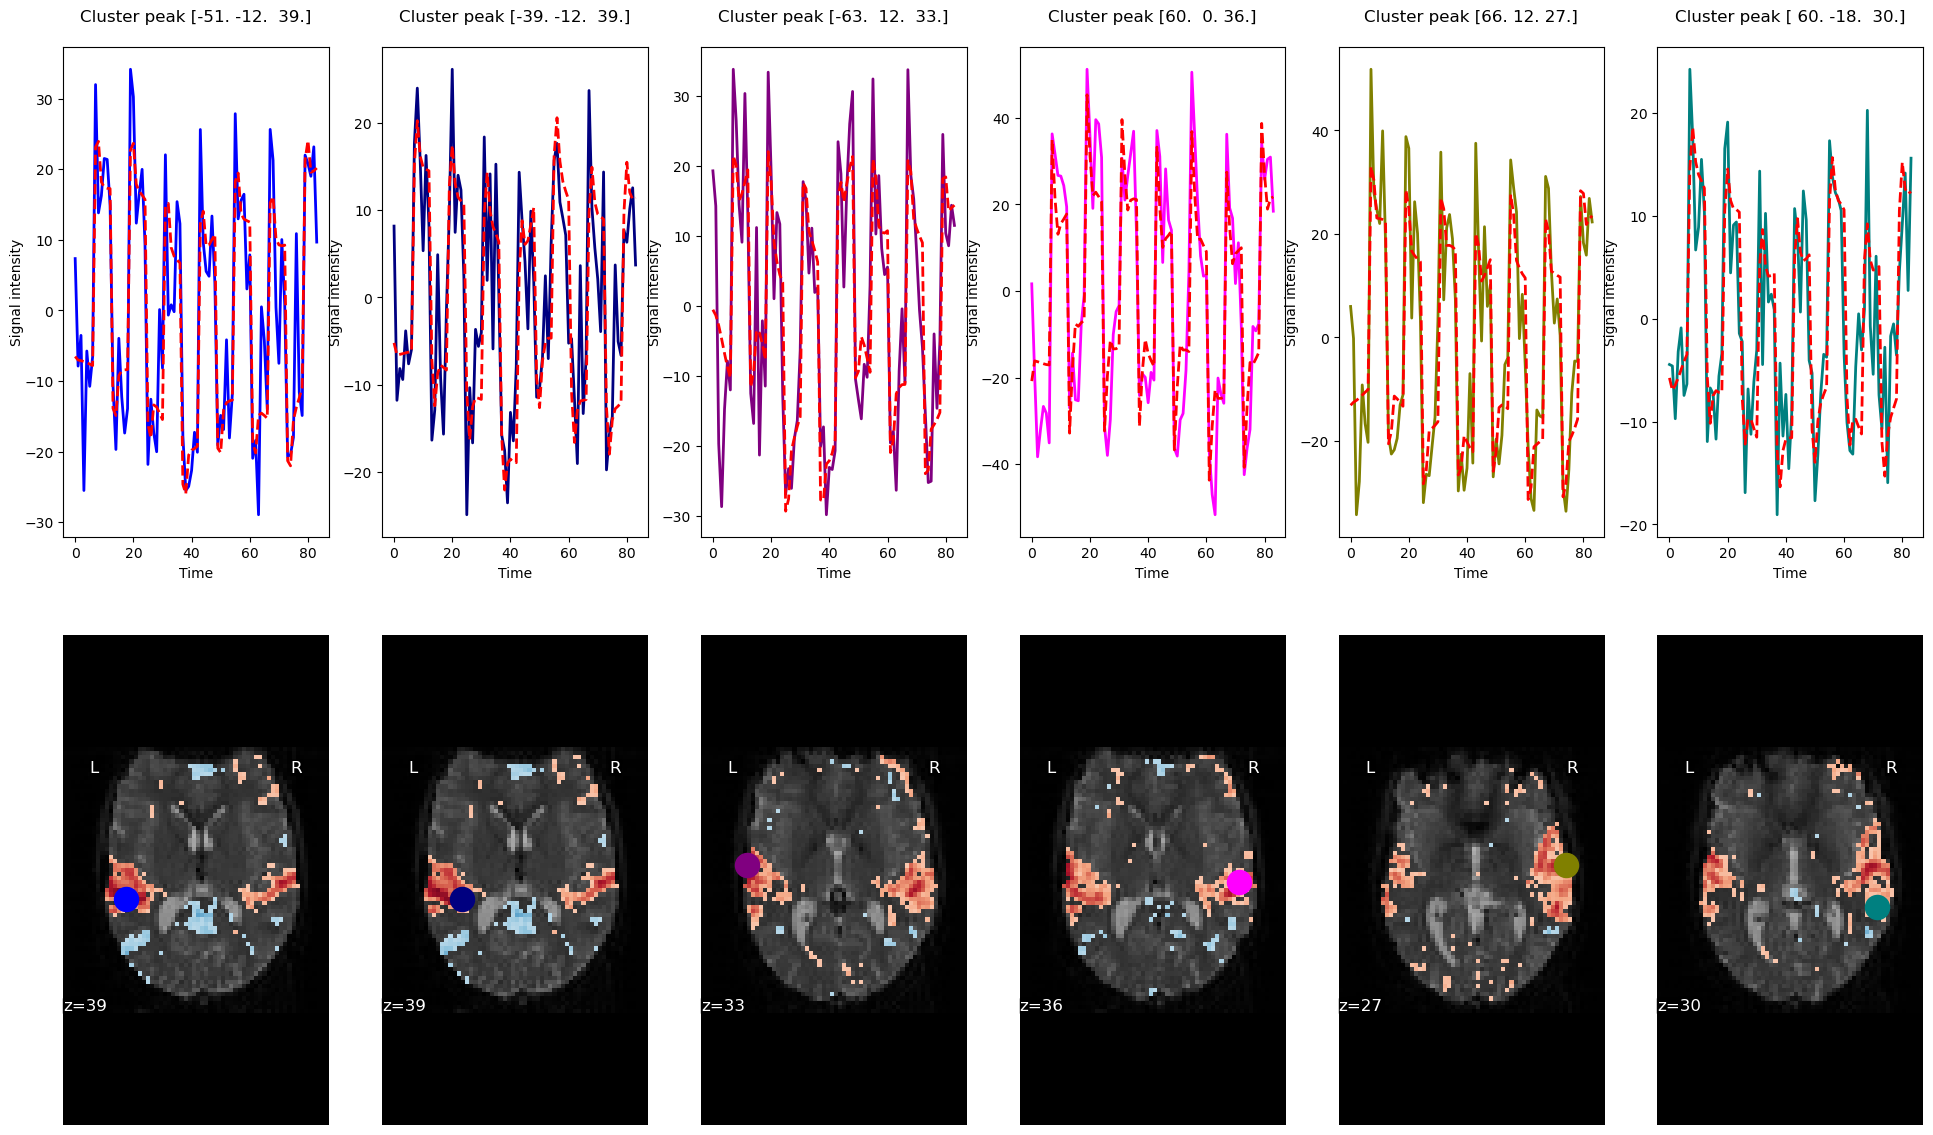

In [14]:
import matplotlib.pyplot as plt

# colors for each of the clusters
colors = ["blue", "navy", "purple", "magenta", "olive", "teal"]
# plot the time series and corresponding locations
fig1, axs1 = plt.subplots(2, 6)
for i in range(6):
    # plotting time series
    axs1[0, i].set_title(f"Cluster peak {coords[i]}\n")
    axs1[0, i].plot(real_timeseries[:, i], c=colors[i], lw=2)
    axs1[0, i].plot(predicted_timeseries[:, i], c="r", ls="--", lw=2)
    axs1[0, i].set_xlabel("Time")
    axs1[0, i].set_ylabel("Signal intensity", labelpad=0)
    # plotting image below the time series
    roi_img = plot_stat_map(
        z_map,
        cut_coords=[coords[i][2]],
        threshold=3.1,
        figure=fig1,
        axes=axs1[1, i],
        display_mode="z",
        colorbar=False,
        bg_img=mean_img,
    )
    roi_img.add_markers([coords[i]], colors[i], 300)
fig1.set_size_inches(24, 14)

show()


<div class='alert alert-warning'>
<b>ToDo</b>:

In your assignment document, answer *Question 4* about actual-fMRI and model-predicted timeseries.
</div>

## Get residuals and plot their distribution
Note that residuals are not really distributed normally.



[NiftiSpheresMasker.wrapped] Finished fit

[NiftiSpheresMasker.wrapped] Loading data from <nibabel.nifti1.Nifti1Image object at 0x15c8ef980>

[NiftiSpheresMasker.wrapped] Extracting region signals

[NiftiSpheresMasker.wrapped] Cleaning extracted signals

Mean residuals: 0.01886940561029727
Mean residuals: 0.04575602612203103
Mean residuals: -4.483186308962537e-15
Mean residuals: -0.1304239304725927
Mean residuals: -0.014998994819338054
Mean residuals: 0.049556260499618955


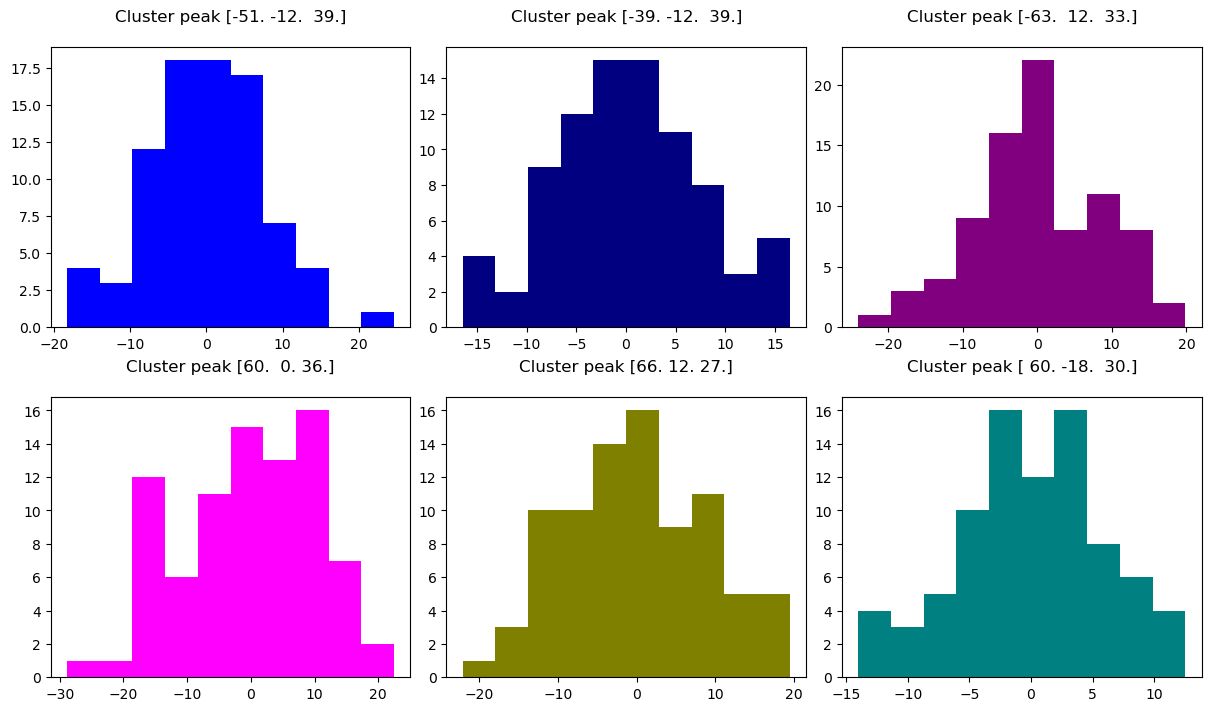

In [17]:
resid = masker.fit_transform(fmri_glm.residuals[0])

fig2, axs2 = plt.subplots(2, 3, constrained_layout=True)

axs2 = axs2.flatten()
for i in range(6):
    axs2[i].set_title(f"Cluster peak {coords[i]}\n")
    axs2[i].hist(resid[:, i], color=colors[i])
    print(f"Mean residuals: {resid[:, i].mean()}")

fig2.set_size_inches(12, 7)

show()


<div class='alert alert-warning'>
<b>ToDo</b>:

In your assignment document, answer *Question 5* about residuals.
</div>

## Plot R-squared

Finally, we can plot the R-squared: the proportion of explained variance of the `GLM` as a whole. Note that the R-squared is markedly lower deep down the brain, where there is more physiological noise and we are further away from the receive coils. 



[FirstLevelModel.r_square] Computing image from signals

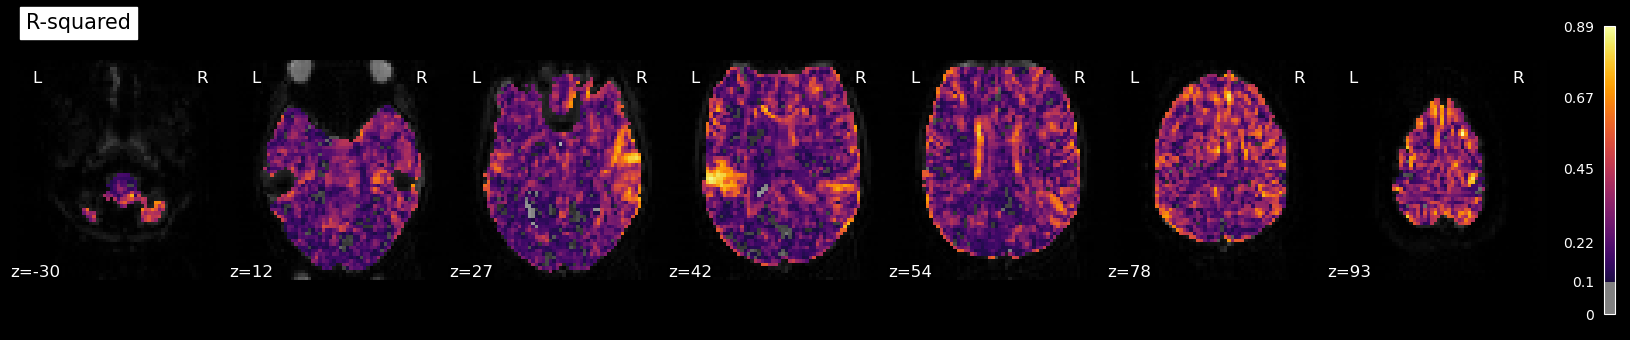

In [10]:
plot_stat_map(
    fmri_glm.r_square[0],
    bg_img=mean_img,
    threshold=0.1,
    display_mode="z",
    cut_coords=7,
    cmap="inferno",
    title="R-squared",
    vmin=0,
    symmetric_cbar=False,
)


<div class='alert alert-warning'>
<b>ToDo</b>:

In your assignment document, answer *Question 6* about assessing the quality of model fits using R-squared.
</div>